# Demographics & Distribution Profiles
This notebook visualizes the distribution of overall ratings, release years, and extracts the top countries, languages, and genres.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/raw/letterboxd.db')
sns.set_theme(style="whitegrid")

Minimum Overall Rating: 1.47
Maximum Overall Rating: 4.68
Average Overall Rating: 3.61


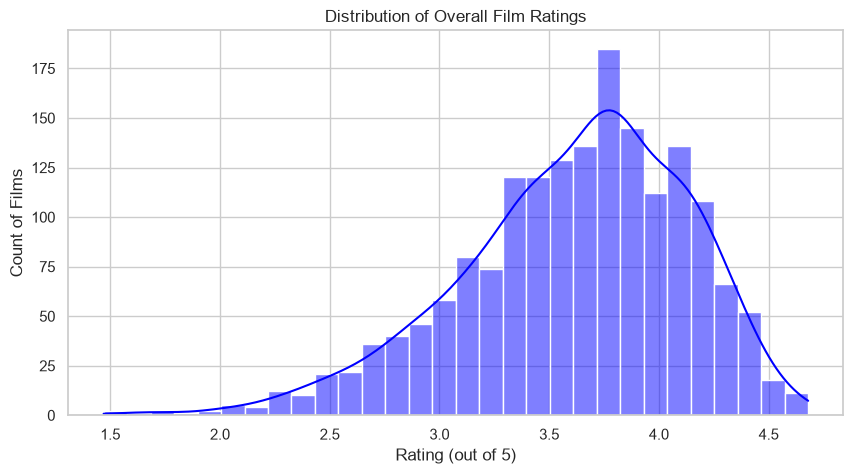

In [2]:
# 1. Overall Rating Profile
df_films = pd.read_sql("SELECT film_name, release_year, CAST(overall_rating AS FLOAT) as rating FROM films", conn)

print(f"Minimum Overall Rating: {df_films['rating'].min():.2f}")
print(f"Maximum Overall Rating: {df_films['rating'].max():.2f}")
print(f"Average Overall Rating: {df_films['rating'].mean():.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(df_films['rating'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Overall Film Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Count of Films')
plt.show()

Oldest Film: 1902
Newest Film: 2026


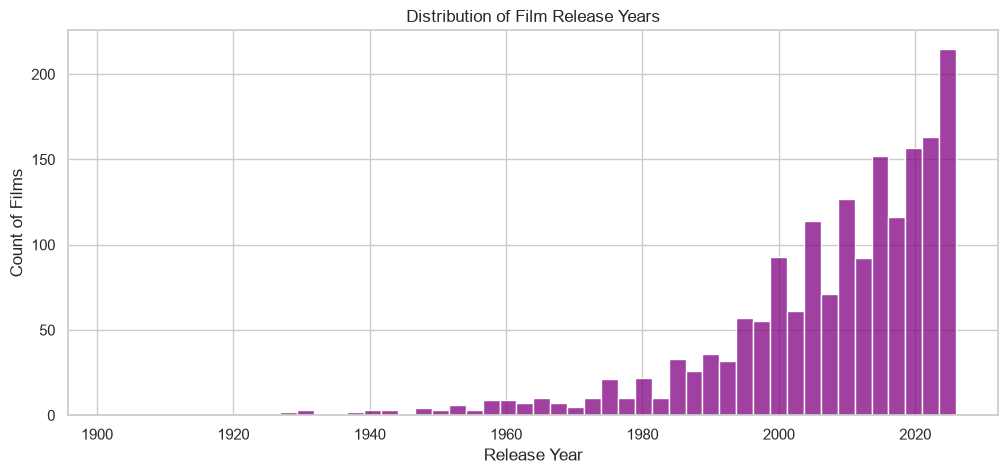

In [3]:
# 2. Release Year Distribution
# Cleaning year data in case of non-standard formats
df_films['release_year_clean'] = pd.to_numeric(df_films['release_year'], errors='coerce')

print(f"Oldest Film: {df_films['release_year_clean'].min()}")
print(f"Newest Film: {df_films['release_year_clean'].max()}")

plt.figure(figsize=(12, 5))
sns.histplot(df_films['release_year_clean'].dropna(), bins=50, color='purple')
plt.title('Distribution of Film Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count of Films')
plt.show()

In [4]:
# 3. Top Countries & Languages
query_details = """
SELECT detail_type, detail_value, COUNT(*) as count 
FROM film_details 
GROUP BY detail_type, detail_value 
ORDER BY count DESC
"""
df_details = pd.read_sql(query_details, conn)

top_countries = df_details[df_details['detail_type'] == 'country'].head(10)
top_languages = df_details[df_details['detail_type'] == 'language'].head(10)

display("Top 10 Countries:", top_countries[['detail_value', 'count']])
display("Top 10 Languages:", top_languages[['detail_value', 'count']])

'Top 10 Countries:'

,detail_value,count
1,USA,1509
2,UK,269
7,France,128
14,Germany,78
15,Japan,76
17,Canada,57
36,Australia,29
38,Italy,28
39,Spain,27
42,Ireland,26


'Top 10 Languages:'

,detail_value,count
0,English,2178
3,French,234
4,Spanish,209
5,Japanese,137
8,German,112
9,Italian,107
13,Russian,80
19,Chinese,54
23,Korean,43
24,Latin,43


C:\Users\Dilhara Jayawardhana\AppData\Local\Temp\ipykernel_24396\4098362977.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_genres, y='genre_name', x='film_count', palette='viridis')


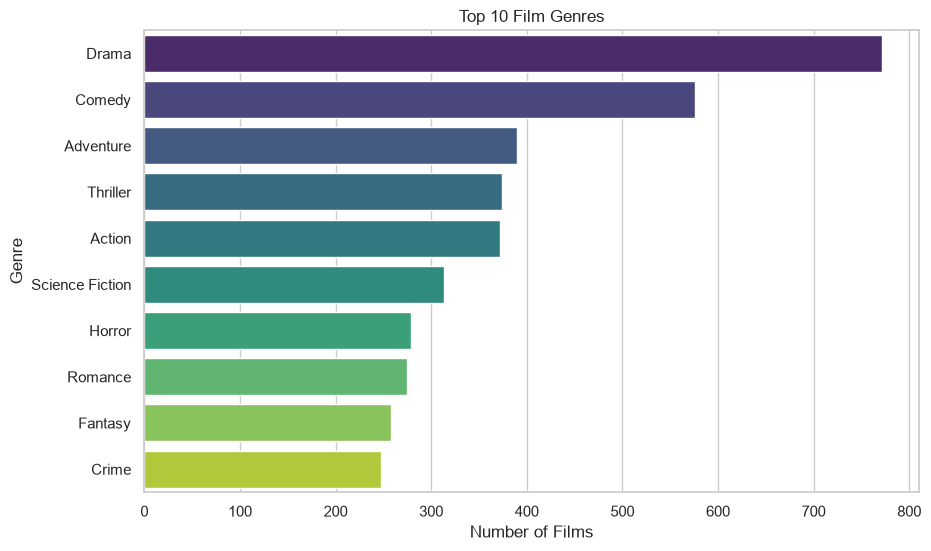

In [5]:
# 4. Top Genres
query_genres = """
SELECT genre_name, COUNT(film_id) as film_count 
FROM film_genres 
GROUP BY genre_name 
ORDER BY film_count DESC 
LIMIT 10
"""
df_top_genres = pd.read_sql(query_genres, conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top_genres, y='genre_name', x='film_count', palette='viridis')
plt.title('Top 10 Film Genres')
plt.xlabel('Number of Films')
plt.ylabel('Genre')
plt.show()